## Compare Number of community

In [11]:
import sys
sys.path.append("../../..")
from utils.processing import json_file_access, evaluate
from beir.retrieval.evaluation import EvaluateRetrieval
from beir.datasets.data_loader import GenericDataLoader
from itertools import combinations
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkit as nk
import pandas as pd
from utils.cs_pipeline import GraphCS
from collections import defaultdict

In [6]:
rq1_ir_res = json_file_access("../../../05_results/rq1/results_rq1.json", "r")
corpus, queries, qrels = GenericDataLoader(data_folder="../../../03_data/raw_data/beir_dbpedia/dbpedia-entity").load(split="test")

  0%|          | 0/4635922 [00:00<?, ?it/s]

In [ ]:
results_rq1 = defaultdict(dict)

for key, value in rq1_ir_res.items():
    for query, result in value.items():
        results_rq1[key][query] = []
        for i, doc_id in enumerate(result.keys()):
            results_rq1[key][query].append(doc_id)

In [23]:
res_all = {}

configuration = {
    "cs_methods": ["LFMLocal", "GCE", "LocalTightnessExpansion","TCE","PageRankNibble"],
    "cs_core_node_number": [10,20,30]
}

# Iteratively add CS Top100
for cs in configuration["cs_methods"]:
    for cs_core_no in configuration["cs_core_node_number"]:
        res_all[cs + "_" + str(cs_core_no)] = json_file_access(f"../../../05_results/rq2/cs/kg1_results_rq2_cs_{cs}_{cs_core_no}.json","r")
# Manually add RQ1 results
res_all["RQ1" + "_" + str(0)] = results_rq1

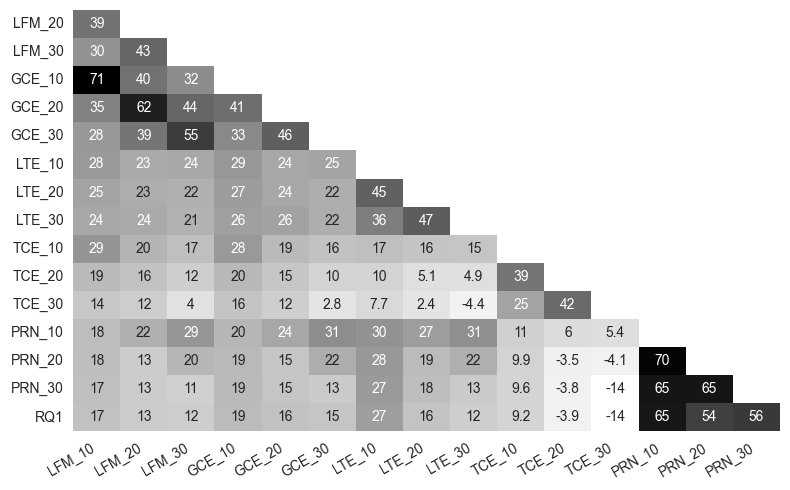

In [9]:
# Abbildung 26
combi_scores = []
combi_labels = []
for combi in combinations(res_all.keys(), 2):
    if "RQ1_0" in combi:
        max(int(combi[0].split("_")[1]),int(combi[1].split("_")[1]))
    else: 
        to_subtract = min(int(combi[0].split("_")[1]),int(combi[1].split("_")[1]))
    mean_intersections = []
    for ir_type in res_all[combi[0]].keys():
        for query in res_all[combi[0]][ir_type].keys():
            mean_intersections.append(len(
                set(res_all[combi[0]][ir_type][query]).intersection(
                set(res_all[combi[1]][ir_type][query])))
                -to_subtract)
    combi_scores.append(statistics.mean(mean_intersections))
    combi_labels.append(f"{combi[0]}-{combi[1]}")

# Create heatmap matrix
n = len(list(res_all.keys()))
heatmap_matrix = np.zeros((n,n))

labels=[]
for x in res_all.keys():
    if x.startswith("LocalTightness"):
        labels.append("LTE_"+x.split("_")[1])
    elif x.startswith("PageRank"):
        labels.append("PRN_"+x.split("_")[1])
    elif x.startswith("RQ1"):
        labels.append("RQ1")
    elif x.startswith("LFM"):
        labels.append("LFM_"+x.split("_")[1])
    else:
        labels.append(x)

# Fill heatmap matrix
idx = 0
for i in range(n):
    for j in range(i+1,n):
        heatmap_matrix[i,j] = combi_scores[idx]
        heatmap_matrix[j,i] = combi_scores[idx]
        idx += 1

# Create mask for upper triangle
mask = np.triu(np.ones_like(heatmap_matrix, dtype=bool))

# Plot heatmap
plt.rcParams["axes.grid"] = False
plt.figure(figsize=(8,5))
ax = sns.heatmap(heatmap_matrix, xticklabels=labels, yticklabels=labels, annot=True, cmap='Greys', mask=mask,cbar=False,)
ax.set_xlim(0,15)
ax.set_ylim(16,1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("Abbildung_26.svg")
plt.show()

# Mean Relevance Points

In [36]:
# Tabelle 12

res_list = defaultdict(dict)

for cs_type in list(res_all.keys())[:-1]:
    cn = int(cs_type.split("_")[1])
    for ir_type in res_all[cs_type].keys():
        res_list[cs_type][ir_type] = {}
        zero_counter = 0
        for query in res_all[cs_type][ir_type].keys():

            relevance_counter_cs = 0
            relevance_counter_all = 0
            
            for doc, relevance in qrels[query].items(): # Loop through all qrel docs
                if relevance > 0:
                    if doc in res_all[cs_type][ir_type][query]: # doc is in the results
                        if doc not in res_all["RQ1_0"][ir_type][query][:cn]: # doc not in the core node results
                            relevance_counter_cs += 1
                            relevance_counter_all += 1
                        else: 
                            relevance_counter_all += 1
            if relevance_counter_cs == 0:
                zero_counter += 1            
            if relevance_counter_all >0:
                res_list[cs_type][ir_type][query] = relevance_counter_cs / relevance_counter_all
        print("Zero Relevant CS results", cs_type,ir_type, zero_counter / len(list(res_all[cs_type][ir_type].keys())))

Zero Relevant CS results LFMLocal_10 boolean 0.6140350877192983
Zero Relevant CS results LFMLocal_10 bm25 0.5338345864661654
Zero Relevant CS results LFMLocal_10 vector 0.46115288220551376
Zero Relevant CS results LFMLocal_10 hybrid 0.41353383458646614
Zero Relevant CS results LFMLocal_20 boolean 0.6290726817042607
Zero Relevant CS results LFMLocal_20 bm25 0.5538847117794486
Zero Relevant CS results LFMLocal_20 vector 0.5012531328320802
Zero Relevant CS results LFMLocal_20 hybrid 0.47869674185463656
Zero Relevant CS results LFMLocal_30 boolean 0.6666666666666666
Zero Relevant CS results LFMLocal_30 bm25 0.568922305764411
Zero Relevant CS results LFMLocal_30 vector 0.5263157894736842
Zero Relevant CS results LFMLocal_30 hybrid 0.5012531328320802
Zero Relevant CS results GCE_10 boolean 0.5413533834586466
Zero Relevant CS results GCE_10 bm25 0.44611528822055135
Zero Relevant CS results GCE_10 vector 0.38847117794486213
Zero Relevant CS results GCE_10 hybrid 0.3157894736842105
Zero Relevan

In [41]:
# TABELLE 11
mean_scores = {}

for cs_type, ir_types in res_list.items():
    for ir_type, queries in ir_types.items():
        scores = list(queries.values())
        mean_score = sum(scores) / len(scores) if scores else 0
        mean_scores[f"{cs_type}_{ir_type}"] = mean_score
# Create a DataFrame from the mean_scores dictionary
mean_scores_df = pd.DataFrame(mean_scores.items(), columns=['cs_ir_type', 'mean_score'])

# Split the 'cs_ir_type' column into 'cs_type' and 'ir_type'
mean_scores_df[['cs_type', 'ir_type']] = mean_scores_df['cs_ir_type'].str.rsplit('_', n=1, expand=True)

# Pivot the DataFrame to have 'cs_type' as columns and 'ir_type' as rows
mean_scores_pivot = mean_scores_df.pivot(index='ir_type', columns='cs_type', values='mean_score')


mean_scores_df["cn"] = mean_scores_df["cs_ir_type"].str.split("_").str[1]
res = mean_scores_df.pivot(index='cs_type', columns=['ir_type'], values='mean_score').reset_index()
res["cs"] = res["cs_type"].str. split("_").str[1]
res["cs_type"] = res["cs_type"].str.split("_").str[0]
res.bm25=res.bm25*100
res.boolean = res.boolean*100
res.vector=res.vector*100
res.hybrid = res.hybrid*100
res.sort_values(["cs","cs_type"], ascending=False)[["cs_type","cs","boolean","bm25","vector","hybrid"]].query("cs_type in ['LocalTightnessExpansion','LFMLocal','GCE']").round(1)

ir_type,cs_type,cs,boolean,bm25,vector,hybrid
8,LocalTightnessExpansion,30,24.2,20.2,26.8,21.7
5,LFMLocal,30,19.6,18.3,21.8,19.0
2,GCE,30,24.8,23.1,26.9,23.9
7,LocalTightnessExpansion,20,31.0,28.2,31.5,29.5
4,LFMLocal,20,25.3,21.7,25.9,23.6
1,GCE,20,31.0,27.4,31.7,29.9
6,LocalTightnessExpansion,10,43.7,42.1,45.6,40.7
3,LFMLocal,10,33.0,30.7,36.2,35.0
0,GCE,10,39.8,37.6,41.3,41.6


In [ ]:
# Tabelle 13

res_list = defaultdict(dict)
cs_type = "RQ1_0"

for cs_type in list(res_all.keys())[:-1]:
    cn = int(cs_type.split("_")[1])
    for ir_type in res_all[cs_type].keys():
        res_list[cs_type][ir_type] = {}
        for query in res_all[cs_type][ir_type].keys():

            relevance_counter_cs = 0
            relevance_counter_all = 0
            
            for doc, relevance in qrels[query].items(): # Loop through all qrel docs
                if relevance > 0:
                    if doc in res_all[cs_type][ir_type][query]: # doc is in the results
                        if doc not in res_all["RQ1_0"][ir_type][query]: # doc not in the core results
                            relevance_counter_cs += 1
                    if doc in res_all["RQ1_0"][ir_type][query]:
                            relevance_counter_all += 1
        
            if relevance_counter_all >0:
                res_list[cs_type][ir_type][query] = relevance_counter_cs / relevance_counter_all

mean_scores = {}

for cs_type, ir_types in res_list.items():
    for ir_type, queries in ir_types.items():
        scores = list(queries.values())
        mean_score = sum(scores) / len(scores) if scores else 0
        mean_scores[f"{cs_type}_{ir_type}"] = mean_score

# Create a DataFrame from the mean_scores dictionary
mean_scores_df = pd.DataFrame(mean_scores.items(), columns=['cs_ir_type', 'mean_score'])

# Split the 'cs_ir_type' column into 'cs_type' and 'ir_type'
mean_scores_df[['cs_type', 'ir_type']] = mean_scores_df['cs_ir_type'].str.rsplit('_', n=1, expand=True)

# Pivot the DataFrame to have 'cs_type' as columns and 'ir_type' as rows
mean_scores_pivot = mean_scores_df.pivot(index='ir_type', columns='cs_type', values='mean_score')


mean_scores_df["cn"] = mean_scores_df["cs_ir_type"].str.split("_").str[1]
res = mean_scores_df.pivot(index='cs_type', columns=['ir_type'], values='mean_score').reset_index()
res["cs"] = res["cs_type"].str.split("_").str[1]
res["cs_type"] = res["cs_type"].str.split("_").str[0]
res.sort_values(["cs","cs_type"], ascending=False)[["cs_type","cs","boolean","bm25","vector","hybrid"]].query("cs_type in ['LocalTightnessExpansion','LFMLocal','GCE']").round(2)

ir_type,cs_type,cs,boolean,bm25,vector,hybrid
8,LocalTightnessExpansion,30,0.28,0.13,0.25,0.13
5,LFMLocal,30,0.22,0.13,0.16,0.11
2,GCE,30,0.25,0.15,0.17,0.12
7,LocalTightnessExpansion,20,0.33,0.15,0.24,0.14
4,LFMLocal,20,0.25,0.12,0.16,0.11
1,GCE,20,0.26,0.13,0.19,0.12
6,LocalTightnessExpansion,10,0.27,0.14,0.24,0.13
3,LFMLocal,10,0.30,0.11,0.19,0.12
0,GCE,10,0.34,0.13,0.20,0.14
